## Part 1: 

Code a function (subroutine) that generates the BA model for an arbitrary value of N
and m. To store the network structure, it is useful to use and adjacency list, that is, a
1
list of lists that associates to each node a list with its nearest neighbors. Instead of a list
of lists, a dictionary can be used, that for each key, corresponding to the index of each
node, assigns as value the list of its nearest neighbors. Lists are useful since they can
grow in the process of generating the BA network. For the generating process, one needs
to select old nodes with probability Eq. (1) to connect the newly added nodes. Sampling
from such changing distribution can be done using an auxiliary list to select the vertices to
which new edges are attached. Add to this array the number i, every time you add a new
connection to vertex i, and m times the number j whenever you add the new vertex j.
Any number i will appear in this way ki times. Selecting uniformly at random an element
in this auxiliary array will give you the number i with probability proportional to ki. Do
not forget the initial nucleus of the network. You can use the random number generator
provided by Python (the high-quality Mersenne-Twister)

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

### Function to Generate BA Network

In [26]:
def generate_BA(N,m):
    
    # Initialize Library
    Network = {node: [] for node in range(N)}



    # Initial nucleus size
    n0 = m + 1

    # Connect every node in the nucleus to each other
    for node1 in range(n0):
            for node2 in range(node1 + 1 , n0):  # More efficient than adding (if node1 != node2) loop
                Network[node1].append(node2)
                Network[node2].append(node1)

    # Debug 
    # print(Network)

    # Initialize Aux. list
    aux_list = []

    # Initialize initial nucleus nodes
    for node in range(n0):
        for i in range(len(Network[node])):
            aux_list.append(node)

    # Debug
    # print(aux_list)


    # Add new nodes from n0 to N (where j is the new node)
    for j in range(n0, N):

        connected_nodes = []
        while len(connected_nodes) < m:
            # Randomly select attachment node
            the_chosen_node = np.random.choice(aux_list)
            if the_chosen_node not in connected_nodes:
                connected_nodes.append(the_chosen_node)

                # Append 'the_chosen_node' at the index 'new_node' in Network
                # Connect the two using the same method as the initial nucleus
                Network[j].append(the_chosen_node)
                Network[the_chosen_node].append(j)


        # Add number i to each connection made
        for i in connected_nodes:
            aux_list.append(i)

        # Add the new node, j * m for each new vertex i
        aux_list.extend([j] * m)  
        
    return Network

### Function for Degree Distribution

We create another function to plot the degree distribution that returns `k_list` which is a list of the degrees with the index being the node.

In [27]:
def create_degree_list(Network, m):

    k_list = []
    mf_approx_list = []
    for node in Network:
        k = len(Network[node])
        k_list.append(k)

        # Mean Field Approx
        mf_approx = (2*(m^2)) / (k^3)
        mf_approx_list.append(mf_approx)



    # Step 1: Plot the degree distribution as a histogram

    # plt.figure(figsize=(8, 6))
    # plt.hist(k_list, bins=range(min(k_list), max(k_list) + 2), edgecolor='black', alpha=0.7, label='Degree Distribution')
    # plt.xlabel('Degree (k)')
    # plt.ylabel('Frequency')
    # plt.title(f'Degree Frequency Distribution\nNetwork Size: {N}')
    # plt.legend()
    # plt.show()

    return k_list

### Plot Equations 3 and 4 Against Degree Distribution

In [28]:
def plot_equations(k_list, N, m):
    # Incorporate Eq. (3) and (4)

    # Create list of degrees from min to max degree in k_list
    degree = range(min(k_list), max(k_list) + 1)

    # Compute P_inf for each degree k in degree
    P_inf = []
    P_N = []
    for k in degree:
        # Compute P_inf, Eq.(3)
        P_inf_i = (2 * m * (m + 1)) / (k * (k+1) * (k+2))
        P_inf.append(P_inf_i)

        # Compute P_N, eq. (4)
        P_N_i = P_inf_i * (k / np.sqrt(N))
        P_N.append(P_N_i)


    # # Plot Probability Distribution P_inf
    # plt.figure()
    # plt.plot(degree, P_inf, marker='o', label="P_inf vs k")
    # plt.xlabel("k")
    # plt.ylabel("P_inf")
    # plt.title("Plot of P_inf vs k")
    # plt.grid(True)
    # plt.legend()
    # plt.show()

    # # Plot Probability Distribution P_N
    # plt.plot(degree, P_N, marker='o', label="P_inf vs k")
    # plt.xlabel("k")
    # plt.ylabel("P_N")
    # plt.title("Plot of P_N vs k")
    # plt.grid(True)
    # plt.legend()
    # plt.show()

    # Plot Probability with Frequency Distribution (Normalized)
    # P_inf
    plt.figure()
    plt.plot(degree, P_inf, marker='o', label="P_inf vs k")
    plt.xlabel("k")
    plt.ylabel("P_inf")
    plt.grid(True)
    plt.legend()

    # P_N
    plt.plot(degree, P_N, marker='o', label="P_inf vs k")
    plt.xlabel("k")
    plt.ylabel("P_inf")
    plt.title("Plot of P_inf vs k")
    plt.grid(True)
    plt.legend()

    # Frequency Distribution
    plt.hist(k_list, bins=range(min(k_list), max(k_list) + 2), density=True, edgecolor='black', alpha=0.7, label='Degree Distribution')
    plt.xlabel('Degree (k)')
    plt.ylabel('Frequency / Approximation')
    plt.title(f'Degree Distribution with Infinite Network Probability\nNetwork Size: {N}')
    plt.legend()
    plt.show()

    return None





### Main Code

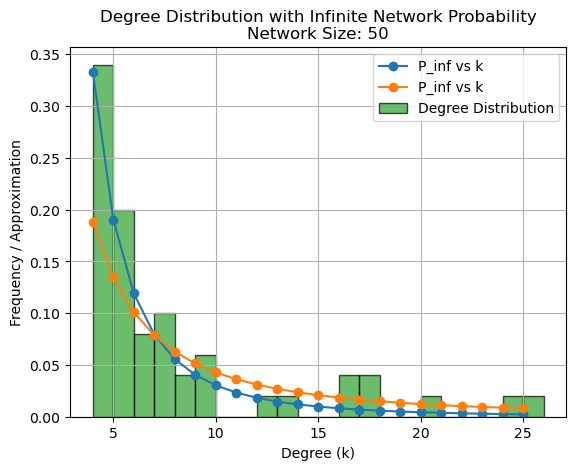

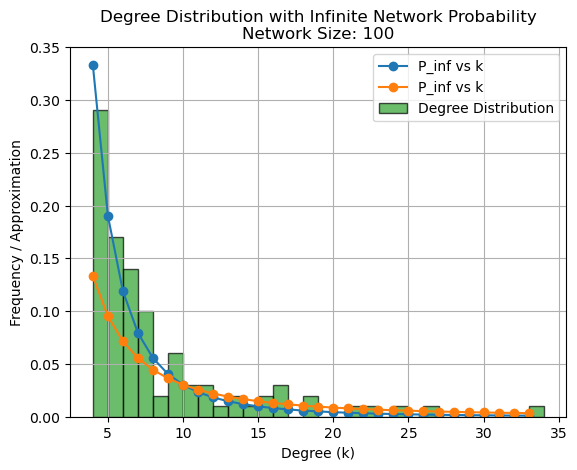

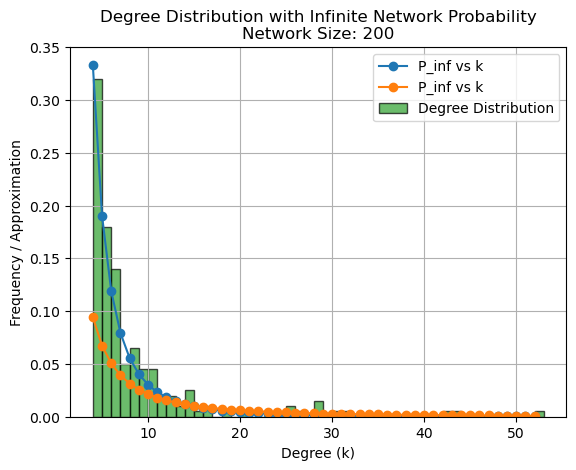

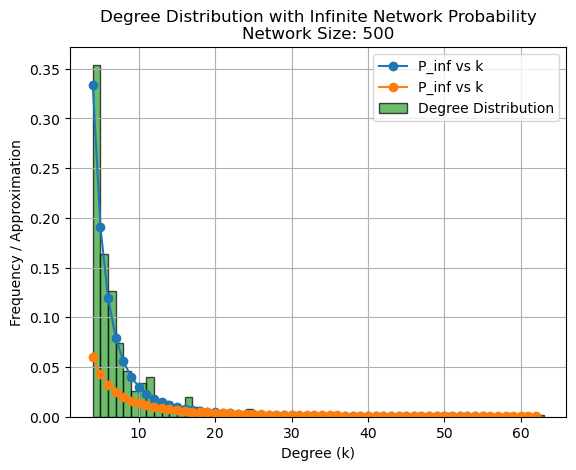

In [29]:
m = 4
N_vals = [50, 100, 200, 500]


for N in N_vals:

    Network = generate_BA(N, m)
    k_list = create_degree_list(Network, m)
    plot_equations(k_list, N, m)


For M different Networks, averaged and then normalized: